In [1]:
import numpy as np
from scipy.integrate import ode,RK45,odeint
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import time
import pandas as pd
from collections import defaultdict

%matplotlib inline

# <center> SOLUCIÓN DEL CIRCUITO DE CHUA </center>

## Marco Teórico

El diodo Chua está caracterizado por una función no lineal de corriente segun el voltaje $i_R=g(v_R)$, cuya pendiente debe ser negativa en algún lugar de la curva, la cual representa la resistencia localmente activa [3]. La función $g$ puede describirse de distintas maneras. El diodo de Chua caracterizado por una funcion de la forma 

<img src="fung.jpg">
<center> <font size=2.5> <strong>Figura 3.</strong> Caracterización del diodo de Chua. [4] </font> </center>

Definida como

\begin{equation} \label{nl_eq}
g(v_R) = \left\{ \begin{array}{lcc}
             m_1v_R &   si  & |v_R| < B_{p_2} \\
             \\ m_1B_{p_2} + m_0(v_R-B_{p_2}) &  si & |v_R| < B_{p_1} \wedge v_R > B_{p_2} \\
             \\ m_1B_{p_2} + m_0(v_R+B_{p_2}) &  si & |v_R| < B_{p_1} \wedge v_R < -B_{p_2} \\
             \\ m_1B_{p_2}+m_0(B_{p_1}-B_{p_2}) - m_{op}(v_R-B_{p_1}) &  si & v_R > B_{p_1} \\
             \\ -m_1B_{p_2}-m_0(B_{p_1}-B_{p_2}) + m_{on}(v_R+B_{p_1}) &  si  & v_R < -B_{p_1}
             \end{array}
   \right.
\end{equation}

Donde $\pm B_{p_1}$ y $\pm B_{p_2}$ se tratan de los puntos de quiebre de $g$, 

Las ecuaciones de estado para el circuito son 

$C1\frac{dV_{C_1}}{dt}=G(V_{C_2}-V_{C_1})-g(V_{C_1})$

$C2\frac{dV_{C_2}}{dt}=G(V_{C_1}-V_{C_2})-i_L$

$L\frac{di_L}{dt}=-V_{C_2}$

Donde 
- $V_{C_1}$ y $V_{C_2}$ son los potenciales sobre los condensadores de capacitancia $C_1$ y $C_2$ respectivamente,
- $i_L$ es la corriente a través del inductor con inductancia $L$ y
- $G=\frac{1}{R}$ la conductancia del resistor lineal.

Los puntos de quiebre se establecen de tal manera que el atractor (el estado en el que se asienta el sistema) permanece en la región de resistencia negativa, así el el atractor estará acotado. Las constantes que le dan forma a la función $g(v_R)$ pueden calcularse de la siguiente manera

$m_0=-\frac{1}{R_3}+\frac{1}{R_4}$

$m_1=-\frac{1}{R_3}-\frac{1}{R_6}$

$B_{p_1}=-\frac{R_3}{R_2+R_3}E_{sat}$

$B_{p_2}=-\frac{R_6}{R_5+R_6}E_{sat}$

$m_{op}=\frac{m_1B_{p_2}+m_0(B_{p_1}-B_{p_2})}{E_{sat}-B_{p_1}}$

$m_{on}=-m_op$

$E_{sat}$ es el voltaje de saturación, determinado por las fuentes de alimentación y la estructura interna de los amplificadores operacionales.

## Resultados
Los parametros de entrada son
$R=1800$ $\Omega$,
$C_1=10$ $nF$,
$C_2=100$ $nF$,
$L=18$ $mH$,
$R_1=220$ $\Omega$,
$R_2=220$ $\Omega$,
$R_3=2200$ $\Omega$,
$R_4=22000$ $\Omega$,
$R_5=22000$ $\Omega$,
$R_6=3300$ $\Omega$,
$E_{sat}=9$ $V$, en base a los valores que propone Kennedy en [4].

In [2]:
#Parametros de entrada

# resistencia fija
R = 1800.0 # Ohm
# capacitancia
C1 = 10.0**-8 # F
C2 = 10.0**-7 # F
# inductancia
L = 18.0 * 10**-3 # H

# resistencias dentro del diodo de Chua
R1 = 220.0 # Ohm
R2 = 220.0 # Ohm
R3 = 2200.0 # Ohm
R4 = 22000.0 # Ohm
R5 = 22000.0 # Ohm
R6 = 3300.0 # Ohm

# Voltaje de saturacion
E_sat = 9.0 # V

G = 1 / R

m01 = 1 / R1
m11 = -1 / R3
BP1 = R3 / (R2 + R3) * E_sat

m02 = 1 / R4
m12 = -1 / R6
BP2 = R6 / (R5 + R6) * E_sat

m0 = m11 + m02
m1 = m11 + m12

qBP2 = m1*BP2
qBP1 = m1*BP2+m0*(BP1-BP2)

m_op = qBP1 / (E_sat - BP1)
m_on = -m_op

def vi_char(v): #Funcion caracteristica de la corriente i [A] en el diodo de chua
    abs_v = abs(v)
    
    if abs_v < BP2:
        # segmento interno
        return m1*v 
    elif abs(v) < BP1:
        # segmentos medios
        if v > 0:
            # lado positivo
            return qBP2 + m0*(v-BP2)
        else:
            # lado negativo
            return -qBP2 + m0*(v+BP2)
    else:
        # segmentos extremos
        if v > 0:
            # lado positivo
            return qBP1 - m_op*(v-BP1)
        else:
            # lado negativo
            return -qBP1 + m_on*(v+BP1)
        
# Condiciones iniciales
t0 = 0
y0 = (0.1,0,0)
u0 = (0, 0,0.1)

# Intervalo de tiempo
t_max = 0.05
dt = 1e-6
num_steps = int(t_max / dt) + 2

array([0.0000e+00, 1.0000e-06, 2.0000e-06, ..., 4.9999e-02, 5.0000e-02,
       5.0001e-02])

### Bifurcación 
A menudo es difícil concluir a partir de únicamente datos experimentales si el comportamiento irregular observado en un experimento se debe al ruido de medición o a una dinámica caótica subyacente. Una bifurcación ocurre cuando un pequeño cambio en los valores de los parámetros de un sistema causa un cambio repentino en su comportamiento, siendo esta una indicación de que se trata de un sistema caótico. [4]

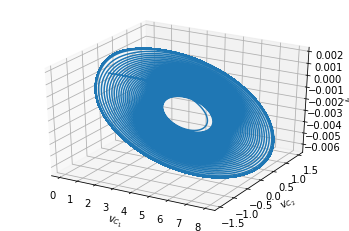

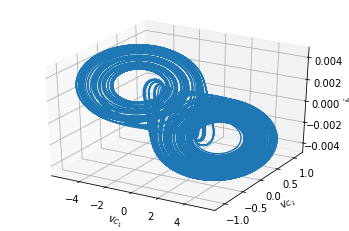

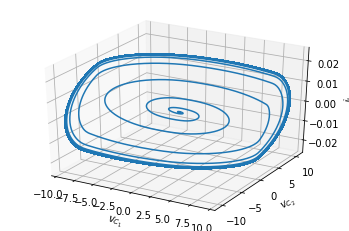

In [3]:
Rs = np.array([2000.0,1850.0,900.0])

for i in range(len(Rs)):
    Gr = 1/Rs[i]
    def chua1(y, t): # Sistema de ecuaciones
        ''' step function for simulation '''
        dv_C1 = (Gr*(y[1]-y[0]) - vi_char(y[0])) / C1
        dv_C2 = (Gr*(y[0]-y[1]) + y[2]) / C2
        di_L = -y[1] / L
        return np.array([dv_C1, dv_C2, di_L])

    solveR = odeint(chua1, y0, np.arange(t0,t_max+dt,dt), full_output=False).T  # llamar rk4
    vC1,vC2,iL = solveR[0,:],solveR[1,:],solveR[2,:]
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.set_xlabel('$v_{C_1}$')
    ax.set_ylabel('$v_{C_2}$')
    ax.set_zlabel('$i_{L}$')

    ax.plot(vC1,vC2,iL)

In [6]:
len(vC1), len(iL), len(vC2)

(50002, 50002, 50002)

(0.0, 0.01)

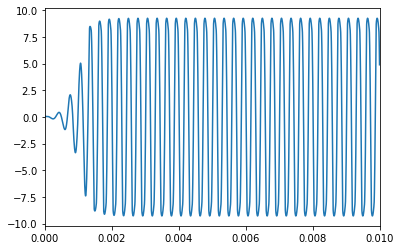

In [15]:
time=np.arange(t0,t_max+dt,dt)
plt.plot(time,vC1)
plt.xlim(0,0.01)

(0.0, 0.01)

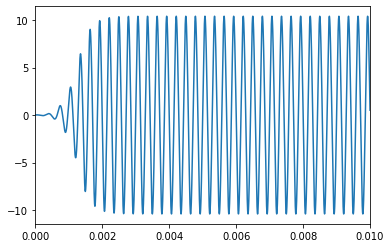

In [17]:
plt.plot(time,vC2)
plt.xlim(0,0.01)

(0.0, 0.01)

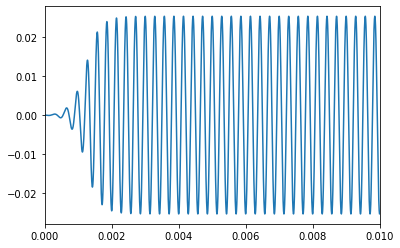

In [20]:
plt. plot(time,iL)
plt.xlim(0,0.01)

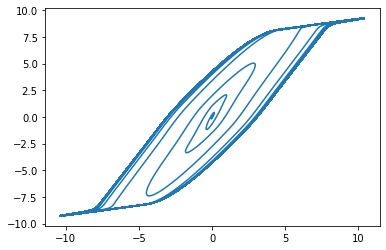

In [22]:
plt.plot(vC2,vC1)

Al variar la resistencia $R$ de $2000$ $\Omega$ a cero, el circuito de Chua exhibe una secuencia de bifurcaciones desde un atractor de Rössler al atractor de scroll doble y luego a un ciclo límite correspondiente a los segmentos externos de la función $g$.

### Condiciones iniciales
Como se mencionó anteriormente el circuito construido tiene un comportamiento caótico, por lo que en particular el comportamiento las soluciones del sistema de estado planteado anteriormente dependerá en gran medida de las condiciones iniciales definidas para $V_{C_1}$, $V_{C_2}$ y $i_L$. La grafica de estas tres variables en el espacio puede describir muchas formas, en particular aquí se muestran 2 de ellas. 

- $V_{C_1}=0$, $V_{C_2}=0$, $i_L=0.1$

NameError: ignored

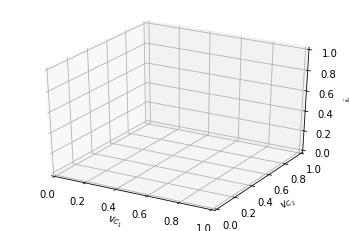

In [ ]:
# 3d-plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('$v_{C_1}$')
ax.set_ylabel('$v_{C_2}$')
ax.set_zlabel('$i_{L}$')

ax.plot(sol_ode_45(u0)[0],sol_ode_45(u0)[1],sol_ode_45(u0)[2])

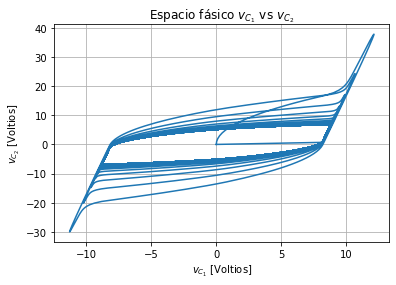

In [ ]:
plt.plot(sol_ode_45(u0)[0],sol_ode_45(u0)[1])
plt.title("Espacio fásico $v_{C_1}$ vs $v_{C_2}$")
plt.xlabel('$v_{C_1}$ [Voltios]')
plt.ylabel('$v_{C_2}$ [Voltios]')
plt.grid()

- $V_{C_1}=0.1$, $V_{C_2}=0$, $i_L=0$

In [ ]:
vC1_45,vC2_45,iL_45 = sol_ode_45(y0)[0],sol_ode_45(y0)[1],sol_ode_45(y0)[2]

# 3d-plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('$v_{C_1}$')
ax.set_ylabel('$v_{C_2}$')
ax.set_zlabel('$i_{L}$')

ax.plot(vC1_45,vC2_45,iL_45)

NameError: ignored

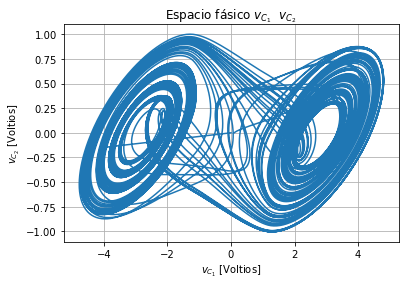

In [ ]:
plt.plot(vC1_45,vC2_45)
plt.title("Espacio fásico $v_{C_1}$  $v_{C_2}$")
plt.xlabel('$v_{C_1}$ [Voltios]')
plt.ylabel('$v_{C_2}$ [Voltios]')
plt.grid()

### Métodos de solución del sistema
La función `odeint` de Scipy resuelve un sistema de ecuaciones diferenciales ordinarias utilizando lsoda de la biblioteca FORTRAN odepack, tal y como lo hace el integrador `lsoda` a través de la clase `ode`.

In [ ]:
def chua2(y, t): # Sistema de ecuaciones
    ''' step function for simulation '''
    dv_C1 = (G*(y[1]-y[0]) - vi_char(y[0])) / C1
    dv_C2 = (G*(y[0]-y[1]) + y[2]) / C2
    di_L = -y[1] / L
    return np.array([dv_C1, dv_C2, di_L])

sol_odeint = odeint(chua2, y0, np.arange(t0,t_max+dt,dt), full_output=False).T
vC1_odeint, vC2_odeint, iL_odeint = sol_odeint[0,:],sol_odeint[1,:],sol_odeint[2,:]

In [ ]:
# Resolver sistema por la funcion ode
def sol_ode_iso(y0): 
    r = ode(derivative).set_integrator('lsoda')
    r.set_initial_value(y0, t0).set_f_params(1)


    v_C1 = np.zeros(num_steps)
    v_C2 = np.zeros(num_steps)
    i_L = np.zeros(num_steps)

    v_C1[0], v_C2[0], i_L[0] = y0

    f = open('output_%d.csv' % int(time.time()), 'w')
    idx = 1
    try:
        while r.successful() and r.t < t_max:
            r.integrate(r.t+dt)

            v_C1[idx], v_C2[idx], i_L[idx] = r.y[0:3]
            idx += 1

            f.write('%f,%f,%f' % tuple(r.y) + ',%f' % r.t + '\n')
    except Exception as e:
        f.close()
        raise e
    f.close()
    
    return v_C1,v_C2,i_L

vC1_iso,vC2_iso,iL_iso = sol_ode_iso(y0)[0],sol_ode_iso(y0)[1],sol_ode_iso(y0)[2]

NameError: ignored

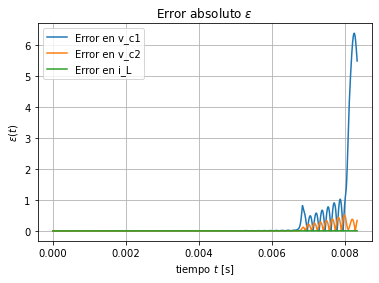

In [ ]:
plt.plot(t,abs(vC1_iso[0:max_interval]-vC1_odeint[0:max_interval]),label='Error en v_c1')
plt.plot(t,abs(vC2_iso[0:max_interval]-vC2_odeint[0:max_interval]),label='Error en v_c2')
plt.plot(t,abs(iL_iso[0:max_interval]-iL_odeint[0:max_interval]),label='Error en i_L')
plt.title("Error absoluto $\epsilon$")
plt.xlabel('tiempo $t$ [s]')
plt.ylabel('$\epsilon(t)$')
plt.grid()
plt.legend()

En la gráfica de las componentes de la solución a primera vista parece que las soluciones obtenidas por los 2 métodos son iguales, sin embargo la gráfica del error absoluto muestra que a medida que avanza el tiempo se tendrá una diferencia cada vez más alta. Asi que a la hora de usar alguna de las 2 funciones que proporciona la librería scipy se ha de tener en cuenta las diferencia entre ambas, por ejemplo, `odeint` tiene una implementación más sencilla, pero las clase `ode` permite escoger entre varios integradores para resolver el sistema.

Por otro lado, la diferencia es mucho menor para los valores de $i_R$ que para $v_{C_1}$ y $v_{C_2}$. Esto puede deberse a que la ecuación diferencial que describe el comportamiento de $i_R$ involucra muchas menos operaciones que las otras dos, y ya que las soluciones que se obtienen por estos metodos son iterativas, los errores de valores anteriores no se propagaran exageradamente.

## Referencias
1. http://nonlinear.eecs.berkeley.edu/chaos/chaos.html
2. http://www.chuacircuits.com/diagram.php
3. http://www.scholarpedia.org/article/Chua_circuit
4. http://www.chaotic-circuits.com/wp-content/uploads/2015/01/ROBUST-OP-AMP-REALIZATION-OF-CHUAS-CIRCUIT.pdf